# VGG 16 with Transfer Learning

### Importing Libraries

In [1]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import tensorflow as tf
from keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D, Dropout
from keras.models import Model
from tensorflow.keras import models, layers
from keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import preprocess_input
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Load Dataset

In [4]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original')

Found 2527 files belonging to 6 classes.


In [5]:
dataset_name = dataset
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
BATCH_SIZE = 32
IMAGE_SIZE = [224,224]
SEED = 123
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

In [7]:
# Load the entire dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset-original',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 2527 files belonging to 6 classes.


In [34]:
# Calculate splits based on NUMBER OF BATCHES (not images)
total_batches = len(full_ds)
num_test_batches = int(total_batches * TEST_SPLIT)
num_val_batches = int(total_batches * VALIDATION_SPLIT)
num_train_batches = total_batches - num_test_batches - num_val_batches

print(f'Total Batches: {total_batches}')
print(f'Batches allocated for Training: {num_train_batches}')
print(f'Batches allocated for Validation: {num_val_batches}')
print(f'Batches allocated for Testing: {num_test_batches}')

# Approximate total images (last batch might be smaller)
approx_total_images = total_batches * BATCH_SIZE
print(f'Approximate Total Images: {approx_total_images}')

# Create datasets using batch-based slicing
train_ds = full_ds.take(num_train_batches)
val_ds = full_ds.skip(num_train_batches).take(num_val_batches)
test_ds = full_ds.skip(num_train_batches + num_val_batches)

def count_images_in_dataset(dataset):
    count = 0
    for batch in dataset:
        count += batch[0].shape[0]  # batch[0] is images, shape[0] is batch size
    return count

print(f'Actual images in train_ds: {count_images_in_dataset(train_ds)}')
print(f'Actual images in val_ds: {count_images_in_dataset(val_ds)}')
print(f'Actual images in test_ds: {count_images_in_dataset(test_ds)}')

Total Batches: 79
Batches allocated for Training: 57
Batches allocated for Validation: 15
Batches allocated for Testing: 7
Approximate Total Images: 2528
Actual images in train_ds: 1824
Actual images in val_ds: 480
Actual images in test_ds: 223


In [35]:
# Use preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [36]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

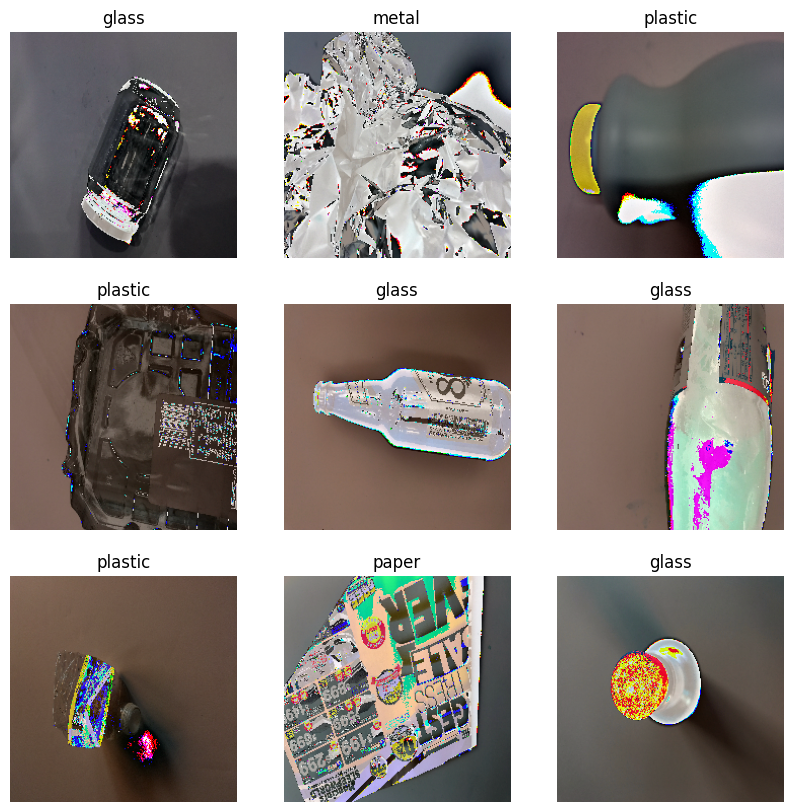

In [11]:
# Display first 9 images

plt.figure(figsize=(10, 10))
for x, y in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x[i].numpy().astype("uint8"))
    plt.title(class_names[y[i]])
    plt.axis("off")

### Data Augmentation

In [12]:
# Create data generator for data augmentation in training set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [13]:
# Create training and validation data generators
train_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(224, 224),  # Resize images to this size
    batch_size=32,
    class_mode='sparse',  # Produce integer labels
    subset='training',  # Set as training data
    seed=123  # for reproducibility
)

val_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation',  # Set as validation data
    seed=123
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [14]:
class_names = train_generator.class_indices  # Returns a dictionary of class names and indices
num_classes = len(train_generator.class_indices)  # Number of classes

print(class_names)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [15]:
# Check the class mappings
print("Class indices:", train_generator.class_indices)
print("Number of classes:", train_generator.num_classes)

# Preview a batch of labels
images, labels = next(train_generator)
print("Labels shape:", labels.shape)
print("First few labels (should be integers):", labels[:10])
print("Labels dtype:", labels.dtype)

Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of classes: 6
Labels shape: (32,)
First few labels (should be integers): [1. 2. 2. 2. 3. 5. 3. 2. 1. 2.]
Labels dtype: float32


### Feature Extraction

## Model

### Stage 1

In [21]:
# Improved model architecture
def create_improved_model(num_classes=6):
    # Load pretrained VGG16
    base_model = tf.keras.applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Add custom head
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

In [22]:
# Create improved model
improved_model, base_model = create_improved_model(len(class_names))

In [25]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,114,310 (57.66 MB)

 Trainable params: 397,574 (1.52 MB)

 Non-trainable params: 14,716,736 (56.14 MB)

In [26]:
# Stage 1: Train only the custom head
print("Stage 1: Training custom head with frozen VGG16...")
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Stage 1: Training custom head with frozen VGG16...


In [27]:
# Callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [28]:
# Train stage 1
history_stage1 = improved_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

print(f"Stage 1 - Best validation accuracy: {max(history_stage1.history['val_accuracy']):.4f}")

C:\Users\Hasya Hazizi\anaconda3\envs\FYP\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 386s 6s/step - accuracy: 0.2190 - loss: 2.2647 - val_accuracy: 0.5070 - val_loss: 1.3376 - learning_rate: 1.0000e-04
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.4261 - loss: 1.5927 - val_accuracy: 0.6561 - val_loss: 1.0403 - learning_rate: 1.0000e-04
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 226s 4s/step - accuracy: 0.5231 - loss: 1.2891 - val_accuracy: 0.6740 - val_loss: 0.9508 - learning_rate: 1.0000e-04
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.5787 - loss: 1.1639 - val_accuracy: 0.6978 - val_loss: 0.8830 - learning_rate: 1.0000e-04
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 227s 4s/step - accuracy: 0.6282 - loss: 1.0081 - val_accuracy: 0.6879 - val_loss: 0.8295 - learning_rate: 1.0000e-04
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.6602 - loss: 0.9370 - val_accuracy: 0.6859 - val_loss: 0.7939 - learning_rate: 1.0000e-04
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.6622 

### Stage 2

In [29]:
base_model.trainable = True

In [30]:
# Fine-tune from this layer onwards
fine_tune_at = 140  # About last 30 layers

# Freeze all layers before fine_tune_at
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [31]:
# Use lower learning rate for fine-tuning
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),  # Lower LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
# Train stage 2
history_stage2 = improved_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

print(f"Stage 2 - Best validation accuracy: {max(history_stage2.history['val_accuracy']):.4f}")

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 323s 5s/step - accuracy: 0.7544 - loss: 0.6752 - val_accuracy: 0.7416 - val_loss: 0.6791 - learning_rate: 1.0000e-05
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 307s 5s/step - accuracy: 0.7194 - loss: 0.7547 - val_accuracy: 0.7475 - val_loss: 0.6681 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 310s 5s/step - accuracy: 0.7361 - loss: 0.7068 - val_accuracy: 0.7515 - val_loss: 0.6982 - learning_rate: 1.0000e-05
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 296s 5s/step - accuracy: 0.7469 - loss: 0.6843 - val_accuracy: 0.7654 - val_loss: 0.6785 - learning_rate: 1.0000e-05
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 327s 5s/step - accuracy: 0.7609 - loss: 0.6906 - val_accuracy: 0.7575 - val_loss: 0.6677 - learning_rate: 1.0000e-05
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 313s 5s/step - accuracy: 0.7098 - loss: 0.7551 - val_accuracy: 0.7674 - val_loss: 0.6551 - learning_rate: 1.0000e-05
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 305s 5s/step - accuracy: 0.7598 

In [37]:
# Combine training histories
def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history[key]
    return combined

combined_history = combine_histories(history_stage1, history_stage2)

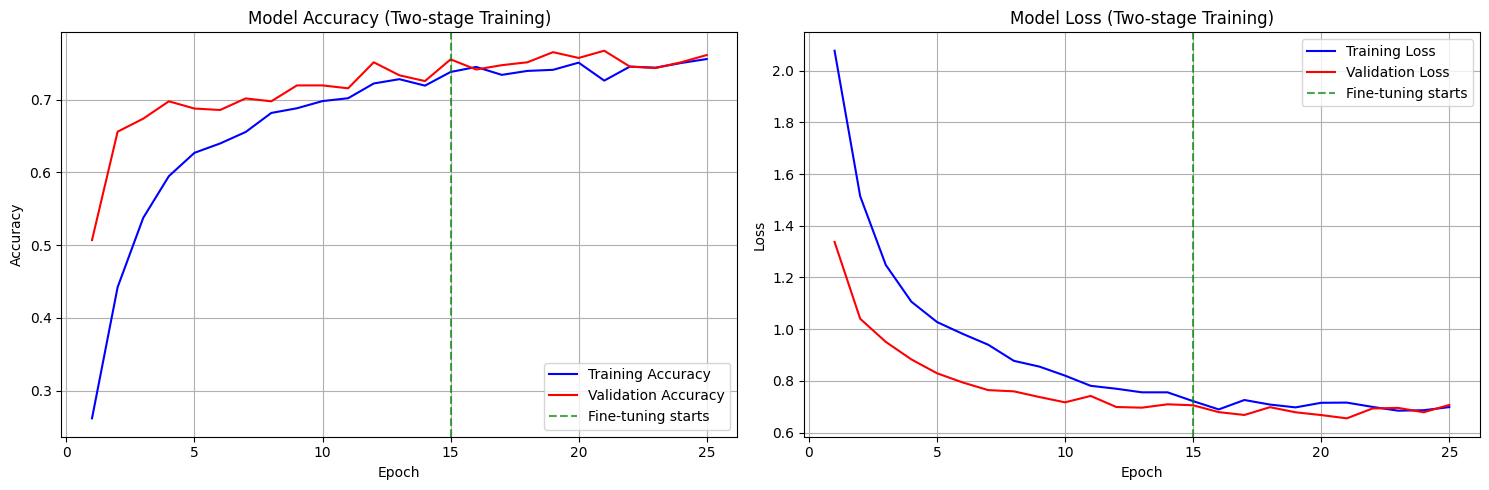

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot with stage separation
epochs_stage1 = len(history_stage1.history['accuracy'])
total_epochs = len(combined_history['accuracy'])

ax1.plot(range(1, total_epochs + 1), combined_history['accuracy'], 'b-', label='Training Accuracy')
ax1.plot(range(1, total_epochs + 1), combined_history['val_accuracy'], 'r-', label='Validation Accuracy')
ax1.axvline(x=epochs_stage1, color='g', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax1.set_title('Model Accuracy (Two-stage Training)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(range(1, total_epochs + 1), combined_history['loss'], 'b-', label='Training Loss')
ax2.plot(range(1, total_epochs + 1), combined_history['val_loss'], 'r-', label='Validation Loss')
ax2.axvline(x=epochs_stage1, color='g', linestyle='--', alpha=0.7, label='Fine-tuning starts')
ax2.set_title('Model Loss (Two-stage Training)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# Final evaluation
print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

final_train_acc = combined_history['accuracy'][-1]
final_val_acc = combined_history['val_accuracy'][-1]
best_val_acc = max(combined_history['val_accuracy'])

print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


FINAL MODEL EVALUATION
Final Training Accuracy: 0.7559 (75.59%)
Final Validation Accuracy: 0.7614 (76.14%)
Best Validation Accuracy: 0.7674 (76.74%)


### Making predictions using test dataset

In [108]:
print(f'Test images (batches): {test_ds.cardinality().numpy()}')

Test images (batches): 7


In [40]:
# Make predictions on the test dataset (test_ds)
y_pred_probs = improved_model.predict(test_ds)

# For multi-class classification, convert probabilities to class predictions
y_pred = np.argmax(y_pred_probs, axis=1)  # Get the predicted classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step  


In [42]:
# Get true labels from validation dataset
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"Number of predictions: {len(y_pred)}")
print(f"Number of true labels: {len(y_true)}")

Number of predictions: 223
Number of true labels: 223


### Measurement matrix

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [44]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
error_rate = 1 - accuracy

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")


MODEL EVALUATION METRICS
Accuracy: 0.1570 (15.70%)
Precision (weighted): 0.1653
Recall (weighted): 0.1570
F1-Score (weighted): 0.1598
Error Rate: 0.8430 (84.30%)


In [45]:
# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cardboard       0.17      0.18      0.18        33
       glass       0.16      0.14      0.15        43
       metal       0.13      0.13      0.13        38
       paper       0.23      0.18      0.20        66
     plastic       0.13      0.17      0.15        35
       trash       0.00      0.00      0.00         8

    accuracy                           0.16       223
   macro avg       0.14      0.13      0.13       223
weighted avg       0.17      0.16      0.16       223




CONFUSION MATRIX
Raw confusion matrix:
[[ 6  8  7  4  7  1]
 [ 6  6  5 15 10  1]
 [ 5  5  5 12  8  3]
 [12 11 11 12 13  7]
 [ 4  7  9  9  6  0]
 [ 2  1  1  1  3  0]]


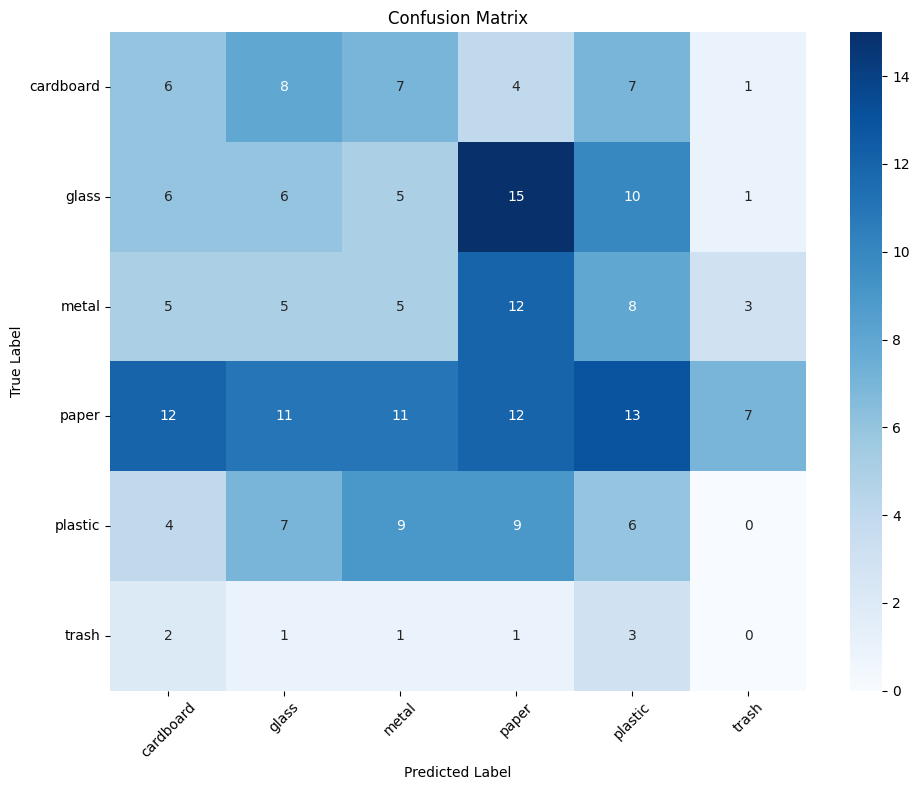

In [46]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print("Raw confusion matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()